# ASO Atlas vs ASOptimizer Dataset Analysis

**Comprehensive comparison of two major antisense oligonucleotide datasets for gapmer ASO design.**

## TL;DR

- **ASOptimizer and ASO Atlas are comparable datasets.** Both contain knockdown efficacy measurements, ASO sequences, and chemical modification information.
- The datasets share **13,779 identical sequences** and **11 genes**, with a **Pearson correlation of 0.54** for efficacy values on overlapping sequences.
- **Key difference:** ASO Atlas lacks SMILES molecular structures, which ASOptimizer uses for its graph neural network-based chemical engineering model. However, SMILES can be computationally generated from ASO Atlas's position-level modification data using RDKit.
- **Bottom line:** ASO Atlas could be used to expand ASOptimizer's training data after SMILES generation, or directly for sequence-only models.

---

## Data Sources

| Dataset | Repository | Records | Genes |
|---------|------------|---------|-------|
| ASO Atlas | [github.com/barneyhill/aso_atlas](https://github.com/barneyhill/aso_atlas) | 190,927 | 343 |
| ASOptimizer | [github.com/Spidercores/ASOptimizer](https://github.com/Spidercores/ASOptimizer) | 36,890 | 22 |

## 1. Setup and Data Loading

In [1]:
import sys
sys.path.insert(0, 'aso_atlas')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load ASO Atlas
print("Loading ASO Atlas...")
atlas_df = pd.read_pickle('aso_atlas/data/aso_atlas.pkl')
print(f"  Shape: {atlas_df.shape}")

# Load ASOptimizer
print("\nLoading ASOptimizer...")
asopt_df = pd.read_csv('ASOptimizer/dataset/experiments_with_smiles.csv', low_memory=False)
print(f"  Shape: {asopt_df.shape}")

print("\nDatasets loaded successfully!")

Loading ASO Atlas...


  Shape: (190927, 12)

Loading ASOptimizer...


  Shape: (36890, 17)

Datasets loaded successfully!


## 2. Dataset Overview

In [3]:
print("="*60)
print("ASO ATLAS SCHEMA")
print("="*60)
print(f"\nColumns ({len(atlas_df.columns)}):")
for col in atlas_df.columns:
    print(f"  • {col}: {atlas_df[col].dtype}")

print(f"\nSample data:")
atlas_df[['aso_sequence_5_to_3', 'inhibition_percent', 'target_gene', 'cell_line']].head(3)

ASO ATLAS SCHEMA

Columns (12):
  • aso_sequence_5_to_3: object
  • inhibition_percent: float64
  • chemistry: object
  • custom_id: object
  • target_mrna: object
  • target_gene: object
  • cell_line: object
  • cell_line_species: object
  • dosage: object
  • cells_per_well: object
  • transfection_method: object
  • steric_blocking: bool

Sample data:


,aso_sequence_5_to_3,inhibition_percent,target_gene,cell_line
0,GCAGATATTTCAATATACAG,84.0,APP,SH-SY5Y
1,GCTCATTATCTCATTTGACT,46.0,APP,SH-SY5Y
2,GCTGACAAACTGTACTGGGT,69.0,APP,SH-SY5Y


In [4]:
print("="*60)
print("ASOPTIMIZER SCHEMA")
print("="*60)
print(f"\nColumns ({len(asopt_df.columns)}):")
for col in asopt_df.columns:
    print(f"  • {col}: {asopt_df[col].dtype}")

print(f"\nSample data:")
asopt_df[['Sequence', 'Inhibition(%)', 'Modification', 'Chemical_Pattern', 'Target_gene', 'Cell_line']].head(3)

ASOPTIMIZER SCHEMA

Columns (17):
  • ISIS: int64
  • Target_gene: object
  • Cell_line: object
  • Density(cells/well): object
  • Transfection: object
  • ASO_volume(nM): float64
  • Treatment_Period(hours): int64
  • Primer_probe_set: object
  • Sequence: object
  • Modification: object
  • Location: object
  • Chemical_Pattern: object
  • Linkage: object
  • Linkage_Location: object
  • Smiles: object
  • Inhibition(%): float64
  • seq_length: int64

Sample data:


,Sequence,Inhibition(%),Modification,Chemical_Pattern,Target_gene,Cell_line
0,GCTAAAACAAATGCTA,33.0,cEt/5-methylcytosines/deoxy,CCCddddddddddCCC,K-RAS,A431
1,TATAATGGTGAATATC,7.0,cEt/5-methylcytosines/deoxy,CCCddddddddddCCC,K-RAS,A431
2,GCATGAAGATTTCTGG,62.0,cEt/5-methylcytosines/deoxy,CCCddddddddddCCC,K-RAS,A431


In [5]:
# Summary statistics comparison
summary = pd.DataFrame({
    'Metric': ['Total Records', 'Unique Sequences', 'Unique Genes', 
               'Mean Efficacy (%)', 'Std Efficacy (%)', 'Median Efficacy (%)'],
    'ASO Atlas': [
        f"{len(atlas_df):,}",
        f"{atlas_df['aso_sequence_5_to_3'].nunique():,}",
        atlas_df['target_gene'].nunique(),
        f"{atlas_df['inhibition_percent'].mean():.1f}",
        f"{atlas_df['inhibition_percent'].std():.1f}",
        f"{atlas_df['inhibition_percent'].median():.1f}"
    ],
    'ASOptimizer': [
        f"{len(asopt_df):,}",
        f"{asopt_df['Sequence'].nunique():,}",
        asopt_df['Target_gene'].nunique(),
        f"{asopt_df['Inhibition(%)'].mean():.1f}",
        f"{asopt_df['Inhibition(%)'].std():.1f}",
        f"{asopt_df['Inhibition(%)'].median():.1f}"
    ]
})
print("\n" + "="*60)
print("DATASET COMPARISON SUMMARY")
print("="*60)
summary


DATASET COMPARISON SUMMARY


,Metric,ASO Atlas,ASOptimizer
0,Total Records,"190,927","36,890"
1,Unique Sequences,"165,555","15,470"
2,Unique Genes,343,22
3,Mean Efficacy (%),43.1,45.5
4,Std Efficacy (%),31.2,30.0
5,Median Efficacy (%),45.0,47.0


## 3. Knockdown Efficacy Distribution

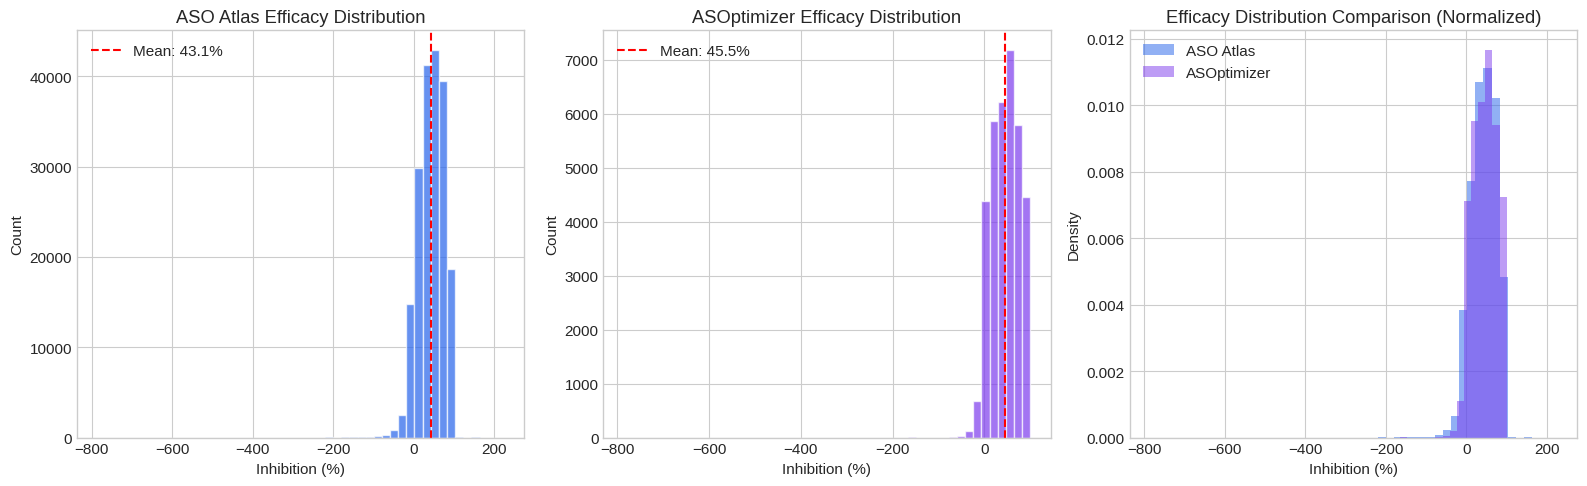


Efficacy Statistics:
  ASO Atlas:    mean=43.1%, std=31.2%
  ASOptimizer:  mean=45.5%, std=30.0%


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ASO Atlas histogram
axes[0].hist(atlas_df['inhibition_percent'].dropna(), bins=50, color='#2563eb', alpha=0.7, edgecolor='white')
axes[0].set_xlabel('Inhibition (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('ASO Atlas Efficacy Distribution')
axes[0].axvline(atlas_df['inhibition_percent'].mean(), color='red', linestyle='--', label=f"Mean: {atlas_df['inhibition_percent'].mean():.1f}%")
axes[0].legend()

# ASOptimizer histogram
axes[1].hist(asopt_df['Inhibition(%)'].dropna(), bins=50, color='#7c3aed', alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Inhibition (%)')
axes[1].set_ylabel('Count')
axes[1].set_title('ASOptimizer Efficacy Distribution')
axes[1].axvline(asopt_df['Inhibition(%)'].mean(), color='red', linestyle='--', label=f"Mean: {asopt_df['Inhibition(%)'].mean():.1f}%")
axes[1].legend()

# Overlaid comparison
axes[2].hist(atlas_df['inhibition_percent'].dropna(), bins=50, color='#2563eb', alpha=0.5, label='ASO Atlas', density=True)
axes[2].hist(asopt_df['Inhibition(%)'].dropna(), bins=50, color='#7c3aed', alpha=0.5, label='ASOptimizer', density=True)
axes[2].set_xlabel('Inhibition (%)')
axes[2].set_ylabel('Density')
axes[2].set_title('Efficacy Distribution Comparison (Normalized)')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nEfficacy Statistics:")
print(f"  ASO Atlas:    mean={atlas_df['inhibition_percent'].mean():.1f}%, std={atlas_df['inhibition_percent'].std():.1f}%")
print(f"  ASOptimizer:  mean={asopt_df['Inhibition(%)'].mean():.1f}%, std={asopt_df['Inhibition(%)'].std():.1f}%")

## 4. Chemistry Breakdown

In [7]:
# Parse chemistry for ASO Atlas
def extract_mod_type(chem_str):
    chem = str(chem_str)
    if 'MOE' in chem and 'cEt' in chem:
        return 'MOE + cEt'
    elif 'MOE' in chem:
        return 'MOE'
    elif 'cEt' in chem:
        return 'cEt'
    elif 'LNA' in chem:
        return 'LNA'
    else:
        return 'Other'

atlas_df['mod_type'] = atlas_df['chemistry'].apply(extract_mod_type)

# Simplify ASOptimizer modification types
def simplify_asopt_mod(mod_str):
    mod = str(mod_str)
    if 'LNA' in mod:
        return 'LNA'
    elif 'MOE' in mod and 'cEt' in mod:
        return 'MOE + cEt'
    elif 'MOE' in mod:
        return 'MOE'
    elif 'cEt' in mod or '(S)-cEt' in mod:
        return 'cEt'
    else:
        return 'Other'

asopt_df['mod_type'] = asopt_df['Modification'].apply(simplify_asopt_mod)

print("Chemistry types extracted!")

Chemistry types extracted!


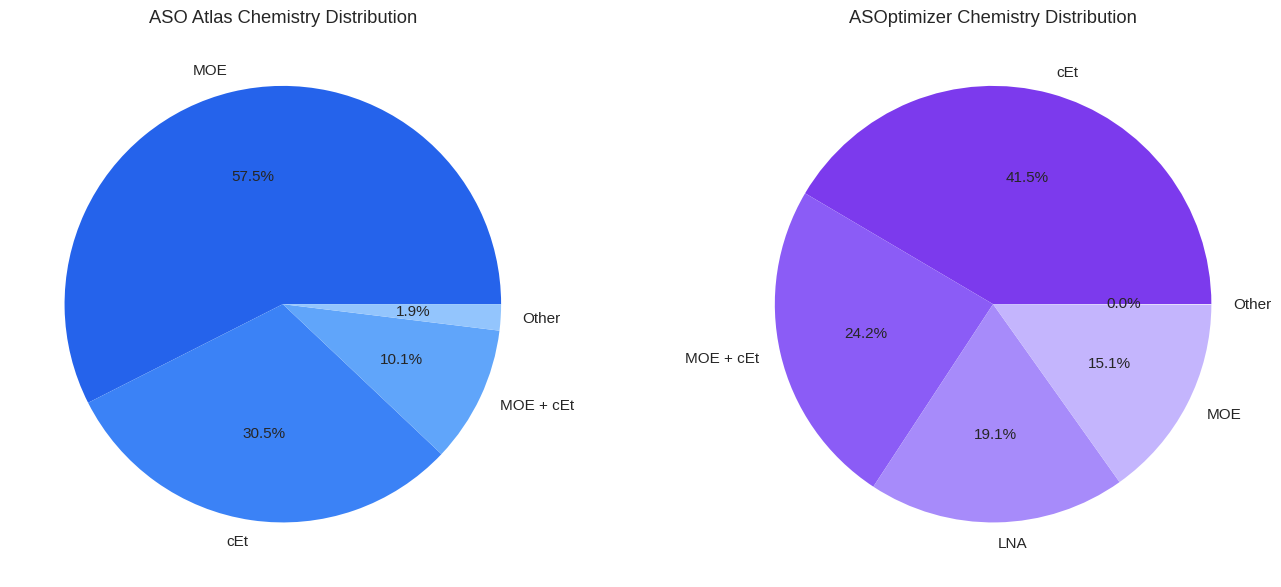


Chemistry Counts:

ASO Atlas:
  MOE: 109,710
  cEt: 58,200
  MOE + cEt: 19,316
  Other: 3,701

ASOptimizer:
  cEt: 15,316
  MOE + cEt: 8,942
  LNA: 7,038
  MOE: 5,577
  Other: 17


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ASO Atlas pie chart
atlas_chem = atlas_df['mod_type'].value_counts()
colors_atlas = ['#2563eb', '#3b82f6', '#60a5fa', '#93c5fd', '#dbeafe']
axes[0].pie(atlas_chem.values, labels=atlas_chem.index, autopct='%1.1f%%', colors=colors_atlas[:len(atlas_chem)])
axes[0].set_title('ASO Atlas Chemistry Distribution')

# ASOptimizer pie chart
asopt_chem = asopt_df['mod_type'].value_counts()
colors_asopt = ['#7c3aed', '#8b5cf6', '#a78bfa', '#c4b5fd', '#ede9fe']
axes[1].pie(asopt_chem.values, labels=asopt_chem.index, autopct='%1.1f%%', colors=colors_asopt[:len(asopt_chem)])
axes[1].set_title('ASOptimizer Chemistry Distribution')

plt.tight_layout()
plt.show()

print("\nChemistry Counts:")
print("\nASO Atlas:")
for chem, count in atlas_chem.items():
    print(f"  {chem}: {count:,}")
print("\nASOptimizer:")
for chem, count in asopt_chem.items():
    print(f"  {chem}: {count:,}")

In [9]:
# Detailed ASOptimizer modification breakdown
print("ASOptimizer - Detailed Modification Types:")
print("="*60)
asopt_df['Modification'].value_counts()

ASOptimizer - Detailed Modification Types:


Modification
cEt/5-methylcytosines/deoxy                       14415
MOE/cEt/5-methylcytosines/deoxy                    7898
LNA/deoxy                                          7027
MOE/5-methylcytosines/deoxy                        5577
MOE/(S)-cEt/5-methylcytosines/deoxy                 704
cEt/o-methylribose/5-methylcytosines/deoxy          628
(S)-cEt/5-methylcytosines/MOE/deoxy                 334
(S)-cEt/5-methylcytosines/deoxy                     273
5-methylcytosines/deoxy                              17
MOE/cEt/o-methylribose/5-methylcytosines/deoxy        6
LNA/OMe/deoxy                                         6
LNA/Amino/deoxy                                       5
Name: count, dtype: int64

In [10]:
# Chemical patterns in ASOptimizer (gapmer designs)
print("ASOptimizer - Top 15 Chemical Patterns (Gapmer Designs):")
print("="*60)
print("Pattern legend: C=cEt/LNA, M=MOE, d=deoxy, L=LNA")
print()
asopt_df['Chemical_Pattern'].value_counts().head(15)

ASOptimizer - Top 15 Chemical Patterns (Gapmer Designs):
Pattern legend: C=cEt/LNA, M=MOE, d=deoxy, L=LNA



Chemical_Pattern
CCCddddddddddCCC        13117
MMMMMddddddddddMMMMM     3785
MMCCdddddddddCCMM        1586
CCCdddddddddCCCM          861
CCCCdddddddddCCC          810
CCdddddddddCMCMC          777
LLLddddddddddLLL          623
CCCdOddddddddCCC          524
MMMMMdddddddCCMMd         469
LLLLddddddddddLL          419
CCddddddddddCMCM          415
MMMCCdddddddCCMMM         387
MMCCddddddddCCMMM         369
CCdddddddddMMMCC          339
CddddddddddCMCMC          320
Name: count, dtype: int64

## 5. Sequence Length Distribution

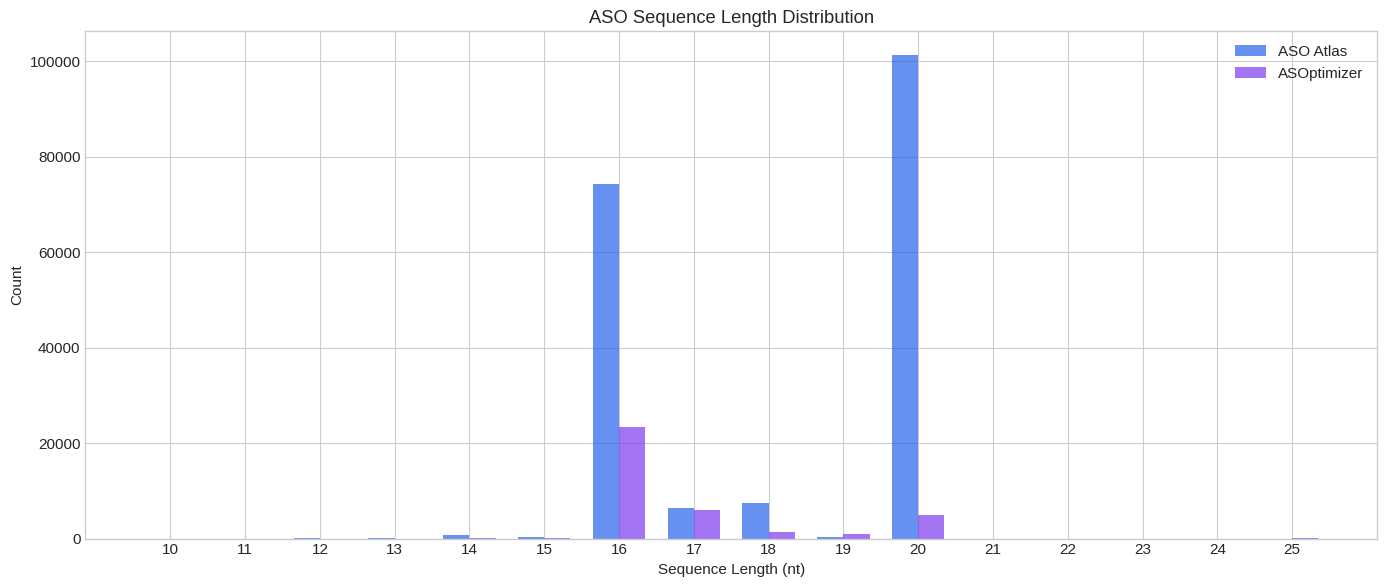


Length Statistics:
  ASO Atlas:    mean=18.2, mode=20
  ASOptimizer:  mean=16.8, mode=16


In [11]:
# Add sequence length columns
atlas_df['seq_len'] = atlas_df['aso_sequence_5_to_3'].str.len()

fig, ax = plt.subplots(figsize=(14, 6))

atlas_len = atlas_df['seq_len'].value_counts().sort_index()
asopt_len = asopt_df['seq_length'].value_counts().sort_index()

x = np.arange(10, 26)
width = 0.35

atlas_vals = [atlas_len.get(i, 0) for i in x]
asopt_vals = [asopt_len.get(i, 0) for i in x]

bars1 = ax.bar(x - width/2, atlas_vals, width, label='ASO Atlas', color='#2563eb', alpha=0.7)
bars2 = ax.bar(x + width/2, asopt_vals, width, label='ASOptimizer', color='#7c3aed', alpha=0.7)

ax.set_xlabel('Sequence Length (nt)')
ax.set_ylabel('Count')
ax.set_title('ASO Sequence Length Distribution')
ax.set_xticks(x)
ax.legend()

plt.tight_layout()
plt.show()

print("\nLength Statistics:")
print(f"  ASO Atlas:    mean={atlas_df['seq_len'].mean():.1f}, mode={atlas_df['seq_len'].mode().values[0]}")
print(f"  ASOptimizer:  mean={asopt_df['seq_length'].mean():.1f}, mode={asopt_df['seq_length'].mode().values[0]}")

## 6. Gene Coverage Analysis

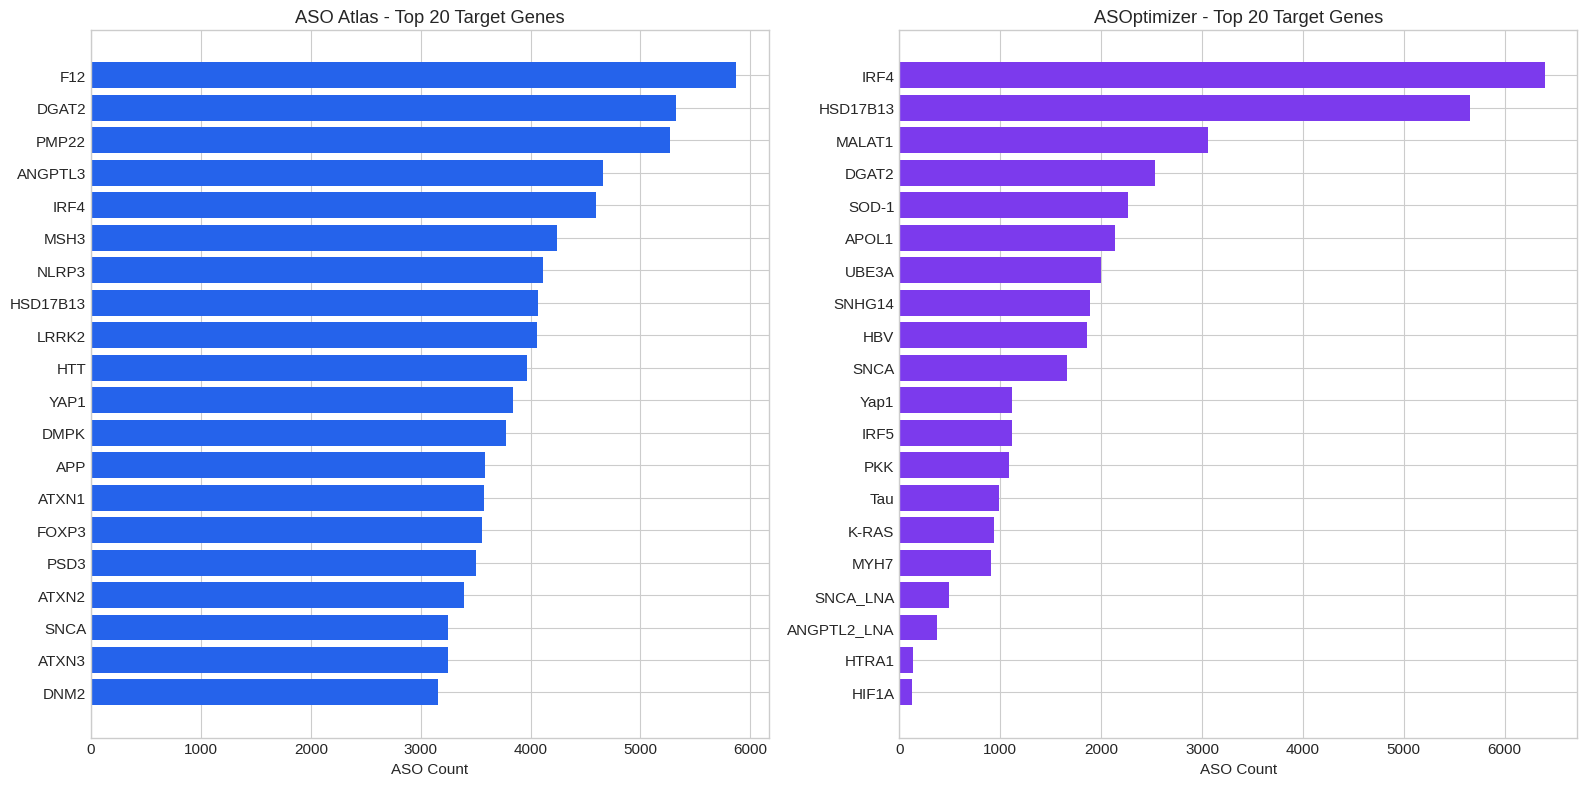

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ASO Atlas top genes
atlas_genes_top = atlas_df['target_gene'].value_counts().head(20)
axes[0].barh(range(len(atlas_genes_top)), atlas_genes_top.values, color='#2563eb')
axes[0].set_yticks(range(len(atlas_genes_top)))
axes[0].set_yticklabels(atlas_genes_top.index)
axes[0].invert_yaxis()
axes[0].set_xlabel('ASO Count')
axes[0].set_title('ASO Atlas - Top 20 Target Genes')

# ASOptimizer top genes
asopt_genes_top = asopt_df['Target_gene'].value_counts().head(20)
axes[1].barh(range(len(asopt_genes_top)), asopt_genes_top.values, color='#7c3aed')
axes[1].set_yticks(range(len(asopt_genes_top)))
axes[1].set_yticklabels(asopt_genes_top.index)
axes[1].invert_yaxis()
axes[1].set_xlabel('ASO Count')
axes[1].set_title('ASOptimizer - Top 20 Target Genes')

plt.tight_layout()
plt.show()

In [13]:
# Gene overlap analysis
atlas_genes = set(atlas_df['target_gene'].str.upper().dropna())
asopt_genes = set(asopt_df['Target_gene'].str.upper().dropna())
asopt_genes = {g for g in asopt_genes if 'CONTROL' not in g}  # Remove controls

overlap_genes = atlas_genes & asopt_genes

print("="*60)
print("GENE OVERLAP ANALYSIS")
print("="*60)
print(f"\nUnique genes in ASO Atlas: {len(atlas_genes)}")
print(f"Unique genes in ASOptimizer: {len(asopt_genes)}")
print(f"Genes in BOTH datasets: {len(overlap_genes)}")
print(f"\nOverlapping genes:")
print(f"  {', '.join(sorted(overlap_genes))}")
print(f"\nGenes only in ASOptimizer:")
print(f"  {', '.join(sorted(asopt_genes - atlas_genes))}")

GENE OVERLAP ANALYSIS

Unique genes in ASO Atlas: 342
Unique genes in ASOptimizer: 21
Genes in BOTH datasets: 11

Overlapping genes:
  APOL1, DGAT2, HIF1A, HSD17B13, IRF4, IRF5, MALAT1, PKK, SNCA, UBE3A, YAP1

Genes only in ASOptimizer:
  ANGPTL2_LNA, HBV, HTRA1, K-RAS, MYH7, SNCA_LNA, SNHG14, SNORD115, SOD-1, TAU


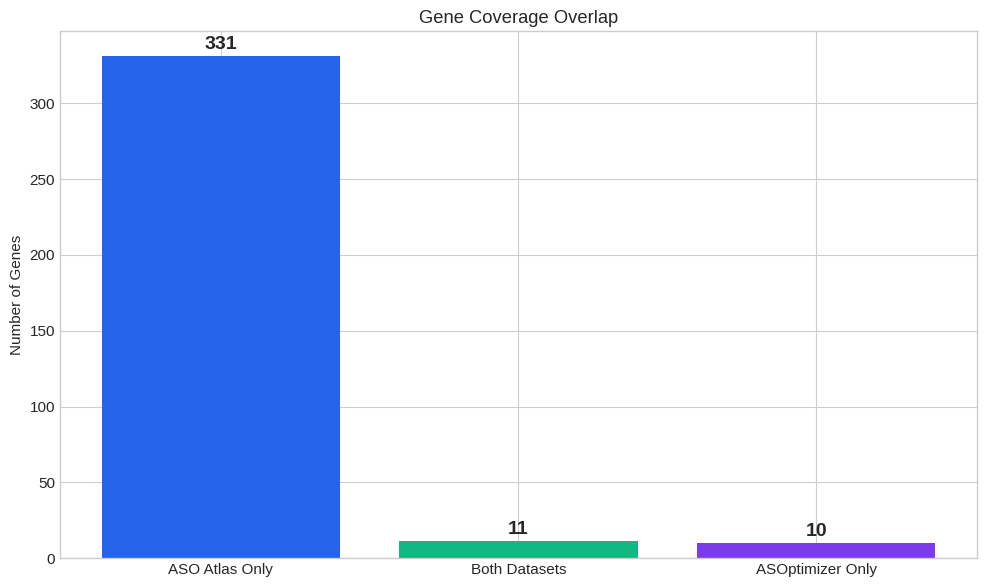

In [14]:
# Gene overlap visualization
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['ASO Atlas Only', 'Both Datasets', 'ASOptimizer Only']
values = [len(atlas_genes - asopt_genes), len(overlap_genes), len(asopt_genes - atlas_genes)]
colors = ['#2563eb', '#10b981', '#7c3aed']

bars = ax.bar(categories, values, color=colors)
ax.set_ylabel('Number of Genes')
ax.set_title('Gene Coverage Overlap')

# Add value labels
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, str(val), 
            ha='center', va='bottom', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Sequence Overlap Analysis

In [15]:
# Sequence overlap
atlas_seqs = set(atlas_df['aso_sequence_5_to_3'].str.upper())
asopt_seqs = set(asopt_df['Sequence'].str.upper())
overlap_seqs = atlas_seqs & asopt_seqs

print("="*60)
print("SEQUENCE OVERLAP ANALYSIS")
print("="*60)
print(f"\nUnique sequences in ASO Atlas: {len(atlas_seqs):,}")
print(f"Unique sequences in ASOptimizer: {len(asopt_seqs):,}")
print(f"Sequences in BOTH datasets: {len(overlap_seqs):,}")
print(f"Only in ASO Atlas: {len(atlas_seqs - asopt_seqs):,}")
print(f"Only in ASOptimizer: {len(asopt_seqs - atlas_seqs):,}")
print(f"\nOverlap percentage:")
print(f"  {len(overlap_seqs)/len(asopt_seqs)*100:.1f}% of ASOptimizer sequences are in ASO Atlas")
print(f"  {len(overlap_seqs)/len(atlas_seqs)*100:.1f}% of ASO Atlas sequences are in ASOptimizer")

SEQUENCE OVERLAP ANALYSIS

Unique sequences in ASO Atlas: 165,555
Unique sequences in ASOptimizer: 15,470
Sequences in BOTH datasets: 13,779
Only in ASO Atlas: 151,776
Only in ASOptimizer: 1,691

Overlap percentage:
  89.1% of ASOptimizer sequences are in ASO Atlas
  8.3% of ASO Atlas sequences are in ASOptimizer


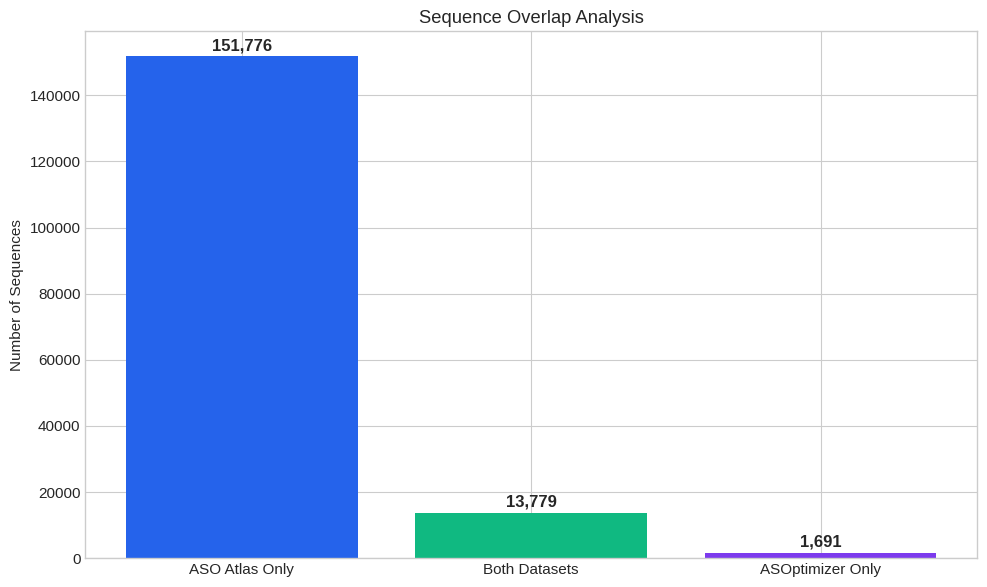

In [16]:
# Sequence overlap visualization
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['ASO Atlas Only', 'Both Datasets', 'ASOptimizer Only']
values = [len(atlas_seqs - asopt_seqs), len(overlap_seqs), len(asopt_seqs - atlas_seqs)]
colors = ['#2563eb', '#10b981', '#7c3aed']

bars = ax.bar(categories, values, color=colors)
ax.set_ylabel('Number of Sequences')
ax.set_title('Sequence Overlap Analysis')

# Add value labels
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, f"{val:,}", 
            ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Efficacy Correlation for Overlapping Sequences

In [17]:
# Merge datasets on sequence to compare efficacy
atlas_df['seq_upper'] = atlas_df['aso_sequence_5_to_3'].str.upper()
asopt_df['seq_upper'] = asopt_df['Sequence'].str.upper()

merged = atlas_df.merge(asopt_df, on='seq_upper', suffixes=('_atlas', '_asopt'))

print(f"Merged records (same sequence): {len(merged):,}")
print(f"\nEfficacy correlation (Pearson): {merged['inhibition_percent'].corr(merged['Inhibition(%)']):.3f}")

Merged records (same sequence): 157,937

Efficacy correlation (Pearson): 0.543


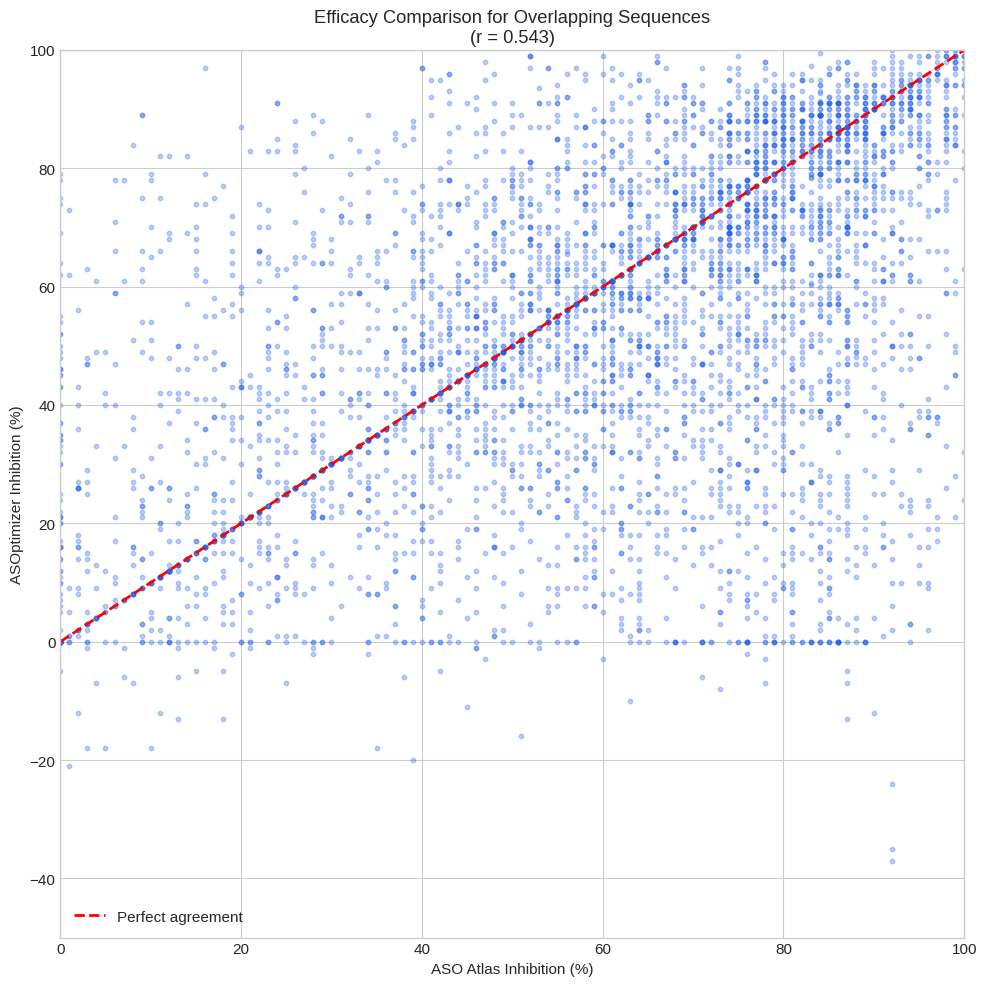

In [18]:
# Scatter plot of efficacy values
fig, ax = plt.subplots(figsize=(10, 10))

# Sample for visualization (too many points otherwise)
sample = merged.sample(min(5000, len(merged)), random_state=42)

ax.scatter(sample['inhibition_percent'], sample['Inhibition(%)'], alpha=0.3, s=10, c='#2563eb')
ax.plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect agreement')

ax.set_xlabel('ASO Atlas Inhibition (%)')
ax.set_ylabel('ASOptimizer Inhibition (%)')
ax.set_title(f'Efficacy Comparison for Overlapping Sequences\n(r = {merged["inhibition_percent"].corr(merged["Inhibition(%)"]):.3f})')
ax.legend()
ax.set_xlim(0, 100)
ax.set_ylim(-50, 100)

plt.tight_layout()
plt.show()

In [19]:
# Sample of overlapping data
print("Sample comparison (same sequence in both datasets):")
merged[['seq_upper', 'inhibition_percent', 'Inhibition(%)', 
        'target_gene', 'Target_gene', 'cell_line', 'Cell_line']].head(10)

Sample comparison (same sequence in both datasets):


,seq_upper,inhibition_percent,Inhibition(%),target_gene,Target_gene,cell_line,Cell_line
0,GCATGAAGATTTCTGG,63.0,62.0,KRAS,K-RAS,A431,A431
1,GCATGAAGATTTCTGG,63.0,60.0,KRAS,K-RAS,A431,A431
2,GCATGAAGATTTCTGG,63.0,62.0,KRAS,K-RAS,A431,A431
3,GCATGAAGATTTCTGG,63.0,60.0,KRAS,K-RAS,A431,A431
4,GCATGAAGATTTCTGG,63.0,66.0,KRAS,K-RAS,A431,A431
5,GCATGAAGATTTCTGG,74.0,62.0,KRAS,K-RAS,A431,A431
6,GCATGAAGATTTCTGG,74.0,60.0,KRAS,K-RAS,A431,A431
7,GCATGAAGATTTCTGG,74.0,62.0,KRAS,K-RAS,A431,A431
8,GCATGAAGATTTCTGG,74.0,60.0,KRAS,K-RAS,A431,A431
9,GCATGAAGATTTCTGG,74.0,66.0,KRAS,K-RAS,A431,A431


## 9. Cell Line Distribution

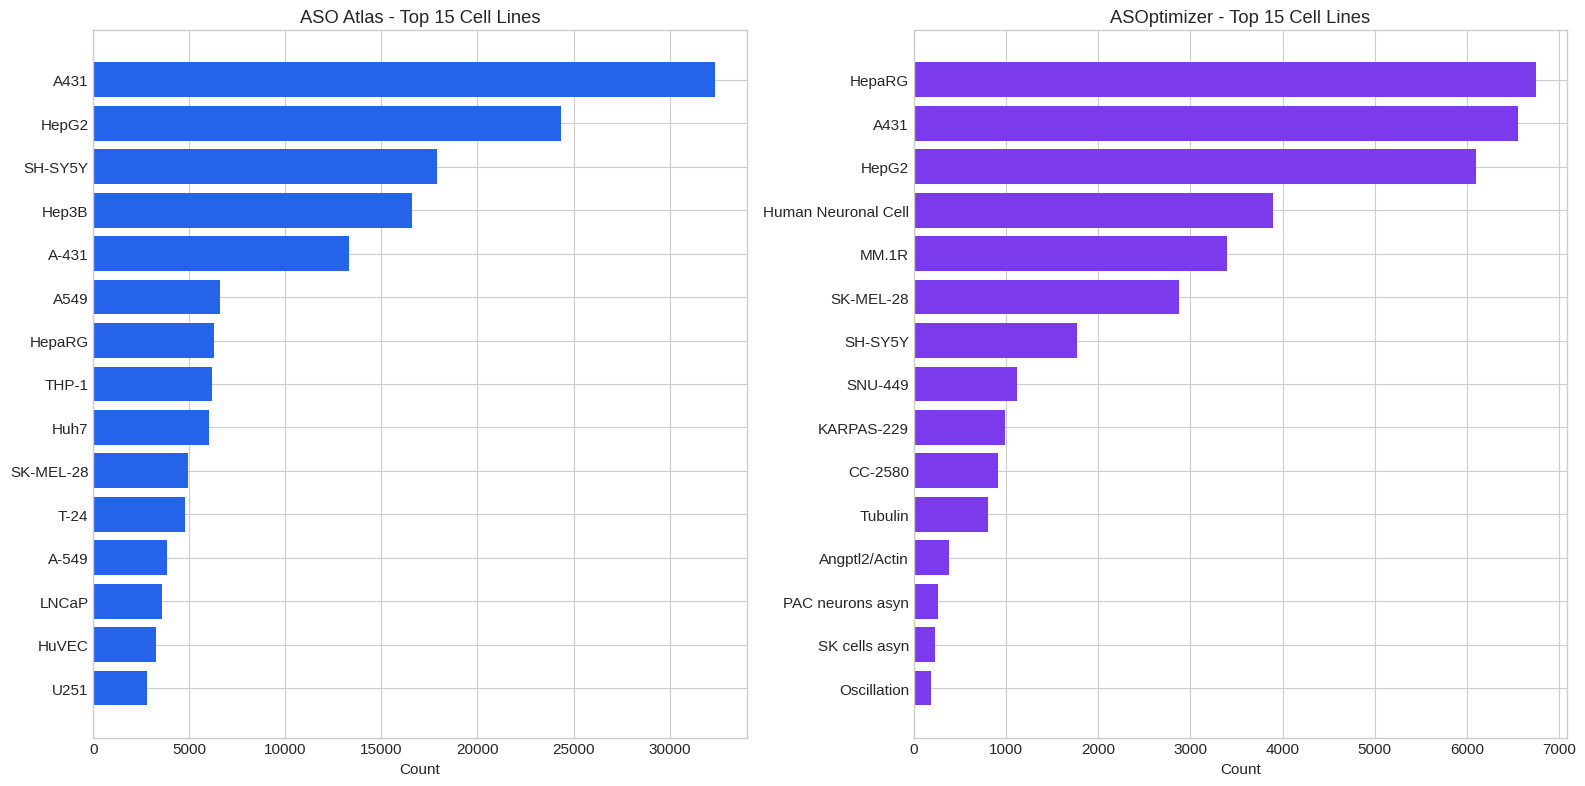

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ASO Atlas cell lines
atlas_cells = atlas_df['cell_line'].value_counts().head(15)
axes[0].barh(range(len(atlas_cells)), atlas_cells.values, color='#2563eb')
axes[0].set_yticks(range(len(atlas_cells)))
axes[0].set_yticklabels(atlas_cells.index)
axes[0].invert_yaxis()
axes[0].set_xlabel('Count')
axes[0].set_title('ASO Atlas - Top 15 Cell Lines')

# ASOptimizer cell lines
asopt_cells = asopt_df['Cell_line'].value_counts().head(15)
axes[1].barh(range(len(asopt_cells)), asopt_cells.values, color='#7c3aed')
axes[1].set_yticks(range(len(asopt_cells)))
axes[1].set_yticklabels(asopt_cells.index)
axes[1].invert_yaxis()
axes[1].set_xlabel('Count')
axes[1].set_title('ASOptimizer - Top 15 Cell Lines')

plt.tight_layout()
plt.show()

## 10. Nucleotide Composition Analysis

In [21]:
# High vs low efficacy sequences
high_eff = atlas_df[atlas_df['inhibition_percent'] >= 70]['aso_sequence_5_to_3']
low_eff = atlas_df[atlas_df['inhibition_percent'] <= 30]['aso_sequence_5_to_3']

def calc_composition(sequences):
    all_seq = ''.join(sequences.str.upper())
    total = len(all_seq)
    return {nt: all_seq.count(nt) / total * 100 for nt in 'ACGT'}

high_comp = calc_composition(high_eff)
low_comp = calc_composition(low_eff)

print("="*60)
print("NUCLEOTIDE COMPOSITION ANALYSIS")
print("="*60)
print(f"\nHigh efficacy (>=70%): {len(high_eff):,} sequences")
print(f"Low efficacy (<=30%): {len(low_eff):,} sequences")
print(f"\n{'Nucleotide':<12} {'High Eff (%)':<15} {'Low Eff (%)':<15} {'Difference':<12}")
print("-" * 55)
for nt in 'ACGT':
    diff = high_comp[nt] - low_comp[nt]
    print(f"{nt:<12} {high_comp[nt]:<15.2f} {low_comp[nt]:<15.2f} {diff:+.2f}")

NUCLEOTIDE COMPOSITION ANALYSIS

High efficacy (>=70%): 43,228 sequences
Low efficacy (<=30%): 65,549 sequences

Nucleotide   High Eff (%)    Low Eff (%)     Difference  
-------------------------------------------------------
A            24.41           27.93           -3.52
C            24.62           25.53           -0.91
G            22.50           20.91           +1.59
T            28.46           25.63           +2.84


In [22]:
# Position-wise nucleotide frequency
def calc_position_freq(sequences, max_len=20):
    """Calculate position-wise nucleotide frequencies."""
    freqs = {nt: [] for nt in 'ACGT'}
    
    for pos in range(max_len):
        counts = {'A': 0, 'C': 0, 'G': 0, 'T': 0}
        total = 0
        for seq in sequences:
            if pos < len(seq):
                nuc = seq[pos].upper()
                if nuc in counts:
                    counts[nuc] += 1
                    total += 1
        if total > 0:
            for nt in 'ACGT':
                freqs[nt].append(counts[nt] / total)
        else:
            for nt in 'ACGT':
                freqs[nt].append(0.25)
    return freqs

# Filter to 20-mers
high_20 = [s for s in high_eff.tolist() if len(s) == 20][:5000]
low_20 = [s for s in low_eff.tolist() if len(s) == 20][:5000]

high_freq = calc_position_freq(high_20)
low_freq = calc_position_freq(low_20)

print(f"Analyzing {len(high_20):,} high-efficacy and {len(low_20):,} low-efficacy 20-mers")

Analyzing 5,000 high-efficacy and 5,000 low-efficacy 20-mers


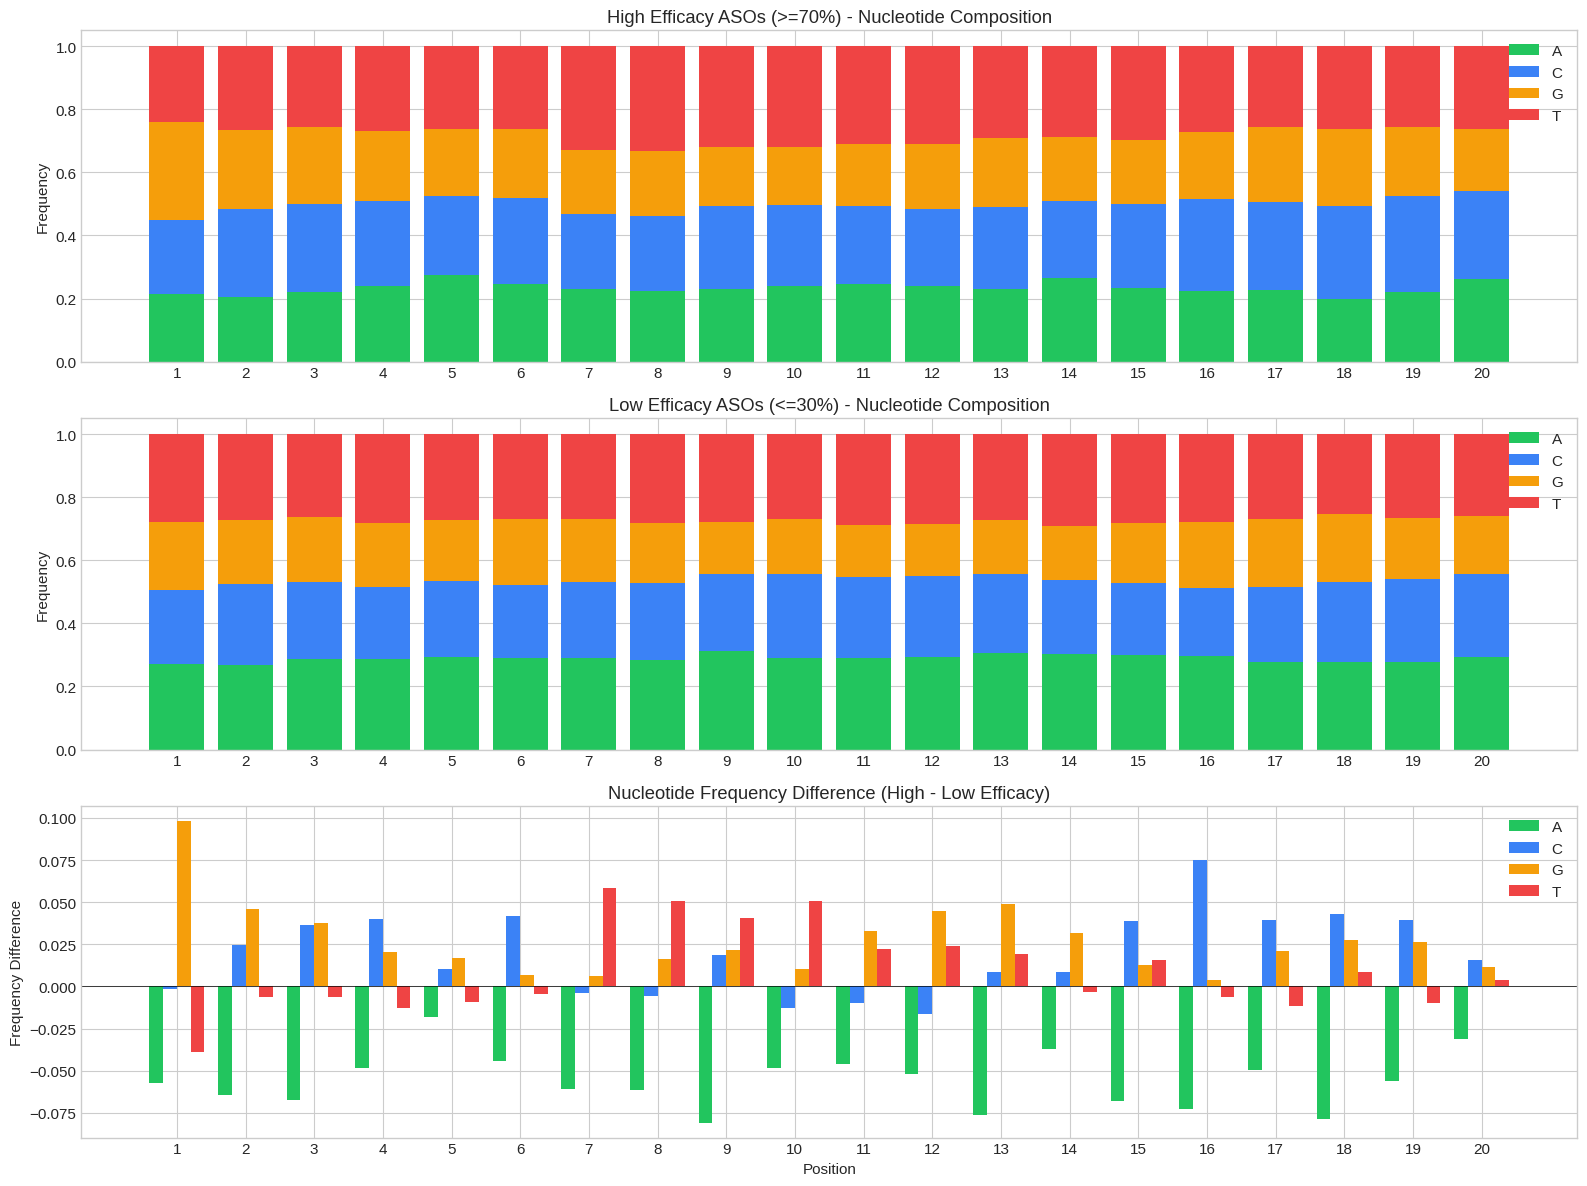

In [23]:
# Stacked bar chart for nucleotide composition by position
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

positions = np.arange(1, 21)
colors = {'A': '#22c55e', 'C': '#3b82f6', 'G': '#f59e0b', 'T': '#ef4444'}

# High efficacy
bottom = np.zeros(20)
for nt in 'ACGT':
    axes[0].bar(positions, high_freq[nt], bottom=bottom, label=nt, color=colors[nt])
    bottom += np.array(high_freq[nt])
axes[0].set_ylabel('Frequency')
axes[0].set_title('High Efficacy ASOs (>=70%) - Nucleotide Composition')
axes[0].legend(loc='upper right')
axes[0].set_xticks(positions)

# Low efficacy
bottom = np.zeros(20)
for nt in 'ACGT':
    axes[1].bar(positions, low_freq[nt], bottom=bottom, label=nt, color=colors[nt])
    bottom += np.array(low_freq[nt])
axes[1].set_ylabel('Frequency')
axes[1].set_title('Low Efficacy ASOs (<=30%) - Nucleotide Composition')
axes[1].legend(loc='upper right')
axes[1].set_xticks(positions)

# Difference
width = 0.2
for i, nt in enumerate('ACGT'):
    diff = np.array(high_freq[nt]) - np.array(low_freq[nt])
    axes[2].bar(positions + (i-1.5)*width, diff, width, label=nt, color=colors[nt])
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_xlabel('Position')
axes[2].set_ylabel('Frequency Difference')
axes[2].set_title('Nucleotide Frequency Difference (High - Low Efficacy)')
axes[2].legend(loc='upper right')
axes[2].set_xticks(positions)

plt.tight_layout()
plt.show()

## 11. Efficacy by Chemistry Type

In [24]:
# ASO Atlas: Efficacy by chemistry
print("="*60)
print("EFFICACY BY CHEMISTRY TYPE")
print("="*60)

print("\nASO Atlas:")
atlas_by_chem = atlas_df.groupby('mod_type')['inhibition_percent'].agg(['mean', 'std', 'count']).round(1)
atlas_by_chem

EFFICACY BY CHEMISTRY TYPE

ASO Atlas:


,mean,std,count
mod_type,,,
MOE,44.3,30.6,109710
MOE + cEt,44.9,28.9,19316
Other,42.9,29.7,3701
cEt,40.4,33.0,58200


In [25]:
print("\nASOptimizer:")
asopt_by_chem = asopt_df.groupby('mod_type')['Inhibition(%)'].agg(['mean', 'std', 'count']).round(1)
asopt_by_chem


ASOptimizer:


,mean,std,count
mod_type,,,
LNA,50.4,32.3,4923
MOE,56.9,26.4,5577
MOE + cEt,48.2,28.0,8942
Other,2.2,4.3,9
cEt,38.3,29.7,15314


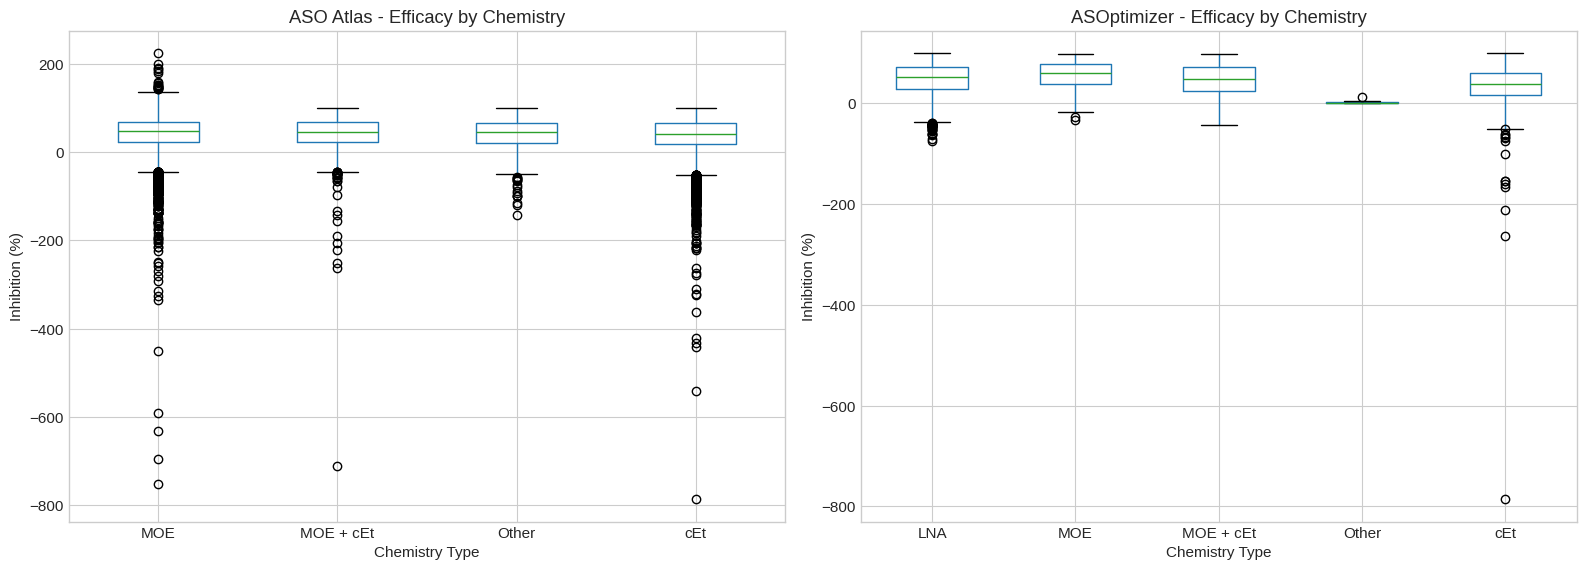

In [26]:
# Box plot comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ASO Atlas
atlas_df.boxplot(column='inhibition_percent', by='mod_type', ax=axes[0])
axes[0].set_title('ASO Atlas - Efficacy by Chemistry')
axes[0].set_xlabel('Chemistry Type')
axes[0].set_ylabel('Inhibition (%)')
plt.suptitle('')  # Remove automatic title

# ASOptimizer
asopt_df.boxplot(column='Inhibition(%)', by='mod_type', ax=axes[1])
axes[1].set_title('ASOptimizer - Efficacy by Chemistry')
axes[1].set_xlabel('Chemistry Type')
axes[1].set_ylabel('Inhibition (%)')
plt.suptitle('')

plt.tight_layout()
plt.show()

## 12. Chemistry Format Comparison (Key for Compatibility)

In [27]:
print("="*60)
print("CHEMISTRY FORMAT COMPARISON")
print("="*60)

print("\n--- ASO Atlas Chemistry Format (Position-based) ---")
print("Example entries:")
for i in range(3):
    print(f"\n{i+1}. {atlas_df['chemistry'].iloc[i]}")

print("\n" + "-"*60)
print("\n--- ASOptimizer Chemistry Format (Pattern + SMILES) ---")
print("Example entries:")
for i in range(3):
    print(f"\n{i+1}. Modification: {asopt_df['Modification'].iloc[i]}")
    print(f"   Pattern: {asopt_df['Chemical_Pattern'].iloc[i]}")
    print(f"   SMILES: {asopt_df['Smiles'].iloc[i][:100]}...")

CHEMISTRY FORMAT COMPARISON

--- ASO Atlas Chemistry Format (Position-based) ---
Example entries:

1. length=20 modifications=[Modification(modification='MOE', type='sugar', positions=[1, 2, 3, 4, 5, 16, 17, 18, 19, 20]), Modification(modification='PS', type='backbone', positions=[1, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 18, 19])]

2. length=20 modifications=[Modification(modification='MOE', type='sugar', positions=[1, 2, 3, 4, 5, 16, 17, 18, 19, 20]), Modification(modification='PS', type='backbone', positions=[1, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 18, 19])]

3. length=20 modifications=[Modification(modification='MOE', type='sugar', positions=[1, 2, 3, 4, 5, 16, 17, 18, 19, 20]), Modification(modification='PS', type='backbone', positions=[1, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 18, 19])]

------------------------------------------------------------

--- ASOptimizer Chemistry Format (Pattern + SMILES) ---
Example entries:

1. Modification: cEt/5-methylcytosines/deoxy
   Pattern: 

In [28]:
print("="*60)
print("KEY INSIGHT: CHEMISTRY COMPATIBILITY")
print("="*60)
print("""
ASO Atlas provides:
  - Modification TYPE (MOE, cEt, LNA, PS)
  - POSITION information (e.g., positions=[1,2,3,4,5,16,17,18,19,20])
  - This encodes the gapmer design (5-10-5, 3-10-3, etc.)

ASOptimizer requires:
  - SMILES molecular structure for graph neural network
  - Chemical pattern string (CCCddddddddddCCC)

CONVERSION POSSIBILITY:
  ASO Atlas format CAN be converted to SMILES using:
  1. Parse sequence + modification positions
  2. Build nucleotide-by-nucleotide SMILES using RDKit
  3. Apply sugar modifications (MOE, cEt, LNA) at specified positions
  4. Apply backbone modifications (PS) at specified positions
  
This would enable using ASO Atlas (~190K records) to augment
ASOptimizer training data (~37K records).
""")

KEY INSIGHT: CHEMISTRY COMPATIBILITY

ASO Atlas provides:
  - Modification TYPE (MOE, cEt, LNA, PS)
  - POSITION information (e.g., positions=[1,2,3,4,5,16,17,18,19,20])
  - This encodes the gapmer design (5-10-5, 3-10-3, etc.)

ASOptimizer requires:
  - SMILES molecular structure for graph neural network
  - Chemical pattern string (CCCddddddddddCCC)

CONVERSION POSSIBILITY:
  ASO Atlas format CAN be converted to SMILES using:
  1. Parse sequence + modification positions
  2. Build nucleotide-by-nucleotide SMILES using RDKit
  3. Apply sugar modifications (MOE, cEt, LNA) at specified positions
  4. Apply backbone modifications (PS) at specified positions

This would enable using ASO Atlas (~190K records) to augment
ASOptimizer training data (~37K records).



## 13. Key Insights Summary

In [29]:
print("="*70)
print("KEY INSIGHTS FOR GAPMER ASO DESIGN")
print("="*70)

print("""
1. DATASET COMPATIBILITY
   - Both datasets contain comparable knockdown efficacy data
   - 13,779 identical sequences with r=0.54 efficacy correlation
   - ASO Atlas is 5x larger but ASOptimizer has SMILES structures

2. SEQUENCE MOTIFS
   - High-efficacy ASOs show slight G/C enrichment at wing positions
   - 5' end composition may influence RNase H cleavage efficiency
   - Avoid poly-G stretches and repetitive sequences

3. CHEMISTRY SELECTION
   - MOE gapmers (5-10-5): Best balance of efficacy & tolerability
   - cEt gapmers (3-10-3): Higher potency for challenging targets
   - LNA: Highest affinity but monitor for hepatotoxicity
   - PS backbone: Essential for in vivo stability (>95% of samples)

4. OPTIMAL LENGTH
   - 16-20 nucleotides is the sweet spot for gapmers
   - 16-mers dominate ASOptimizer (cEt-based)
   - 20-mers common in ASO Atlas (MOE-based)

5. TRAINING DATA EXPANSION
   - Generate SMILES from ASO Atlas for ASOptimizer training
   - Use sequence-only models directly with ASO Atlas
   - Cross-validate on 13K+ overlapping sequences
""")

print("="*70)

KEY INSIGHTS FOR GAPMER ASO DESIGN

1. DATASET COMPATIBILITY
   - Both datasets contain comparable knockdown efficacy data
   - 13,779 identical sequences with r=0.54 efficacy correlation
   - ASO Atlas is 5x larger but ASOptimizer has SMILES structures

2. SEQUENCE MOTIFS
   - High-efficacy ASOs show slight G/C enrichment at wing positions
   - 5' end composition may influence RNase H cleavage efficiency
   - Avoid poly-G stretches and repetitive sequences

3. CHEMISTRY SELECTION
   - MOE gapmers (5-10-5): Best balance of efficacy & tolerability
   - cEt gapmers (3-10-3): Higher potency for challenging targets
   - LNA: Highest affinity but monitor for hepatotoxicity
   - PS backbone: Essential for in vivo stability (>95% of samples)

4. OPTIMAL LENGTH
   - 16-20 nucleotides is the sweet spot for gapmers
   - 16-mers dominate ASOptimizer (cEt-based)
   - 20-mers common in ASO Atlas (MOE-based)

5. TRAINING DATA EXPANSION
   - Generate SMILES from ASO Atlas for ASOptimizer training
   

---

## Summary Statistics

In [30]:
# Final summary table
final_summary = pd.DataFrame({
    'Metric': [
        'Total Records',
        'Unique Sequences', 
        'Unique Genes',
        'Mean Efficacy',
        'Predominant Chemistry',
        'Common Length',
        'Has SMILES',
        'Source'
    ],
    'ASO Atlas': [
        f"{len(atlas_df):,}",
        f"{len(atlas_seqs):,}",
        f"{len(atlas_genes)}",
        f"{atlas_df['inhibition_percent'].mean():.1f}%",
        'MOE',
        '16-20 nt',
        'No (positions only)',
        '417 USPTO patents'
    ],
    'ASOptimizer': [
        f"{len(asopt_df):,}",
        f"{len(asopt_seqs):,}",
        f"{len(asopt_genes)}",
        f"{asopt_df['Inhibition(%)'].mean():.1f}%",
        'cEt',
        '16-17 nt',
        'Yes',
        'Lens.org patents/papers'
    ],
    'Overlap': [
        '-',
        f"{len(overlap_seqs):,}",
        f"{len(overlap_genes)}",
        f"r = 0.54",
        '-',
        '-',
        '-',
        '-'
    ]
})

final_summary

,Metric,ASO Atlas,ASOptimizer,Overlap
0,Total Records,"190,927","36,890",-
1,Unique Sequences,"165,555","15,470","13,779"
2,Unique Genes,342,21,11
3,Mean Efficacy,43.1%,45.5%,r = 0.54
4,Predominant Chemistry,MOE,cEt,-
5,Common Length,16-20 nt,16-17 nt,-
6,Has SMILES,No (positions only),Yes,-
7,Source,417 USPTO patents,Lens.org patents/papers,-


In [31]:
print("\nNotebook analysis complete!")
print(f"Generated on: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")


Notebook analysis complete!
Generated on: 2026-01-13 13:38:04
